# Project Title

**Fake News Detection Using Machine Learning Algorithms**

#  Problem Statement

With the rapid growth of digital media platforms and social networking websites, millions of news articles are published every day. Among them, a significant amount of fake news is circulated, which can mislead people, spread misinformation, and create confusion in society. Manual verification of news articles is time-consuming, inefficient, and often impractical due to the large volume of information available online.

The main objective of this project is to develop an automated Fake News Detection System using Machine Learning techniques. By applying text preprocessing, TF-IDF vectorization, and classification algorithms, the system can accurately classify news articles as either fake or genuine.

#  Objectives

* To identify and classify fake and genuine news articles.
* To preprocess textual data for machine learning applications.
* To apply TF-IDF (Term Frequency–Inverse Document Frequency) for feature extraction.
* To compare the performance of multiple Machine Learning algorithms.
* To select the model with the highest accuracy for fake news detection.

#  Dataset Description

The project uses two datasets:

## Fake.csv

This dataset contains fake news articles.

**Columns:**

* Title
* Text
* Subject
* Date

## True.csv

This dataset contains genuine news articles.

**Columns:**

* Title
* Text
* Subject
* Date

## Dataset Preparation

The datasets were combined into a single dataset and labeled as follows:

* **Fake News → Label = 0**
* **Genuine News → Label = 1**

These labels were used as target variables for training and testing the Machine Learning models.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Dataset loading

In [2]:
fake = pd.read_csv(r"D:\mlproject\Fake.csv")

In [3]:
true = pd.read_csv(r"D:\mlproject\True.csv")

In [4]:
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [5]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


## Data Preprocessing

### Assign Labels (0 and 1)

In [6]:
true['label'] = 1

In [7]:
fake['label'] = 0

In [8]:
true.head()

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


### Combine Datasets

In [9]:
news = pd.concat([fake, true], axis=0)

In [10]:
news.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [11]:
news.tail()

,title,text,subject,date,label
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",1
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",1
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",1
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",1
21416,Indonesia to buy $1.14 billion worth of Russia...,JAKARTA (Reuters) - Indonesia will buy 11 Sukh...,worldnews,"August 22, 2017",1


## Data cleaning

### Check missing values 

In [12]:
news.isnull().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

### Remove unwanted columns

In [13]:
news = news.drop(['title','subject','date'],axis = 1)

In [14]:
news.head()

,text,label
0,Donald Trump just couldn t wish all Americans ...,0
1,House Intelligence Committee Chairman Devin Nu...,0
2,"On Friday, it was revealed that former Milwauk...",0
3,"On Christmas day, Donald Trump announced that ...",0
4,Pope Francis used his annual Christmas Day mes...,0


## Reshuffling

In [15]:
news = news.sample(frac=1)                #Reshuffling

In [16]:
news.head()

,text,label
294,"BIRMINGHAM, Ala. (Reuters) - Name-calling is n...",1
18814,Pepsi got hammered by just about everyone for ...,0
20085,SARAJEVO (Reuters) - Police in the Balkans hav...,1
7322,WASHINGTON (Reuters) - Criminal justice reform...,1
13298,Donald Trump has done so many things that you ...,0


In [17]:
news.reset_index(inplace=True)     #rearrange row numbers in a dataframe after merging or modifying data.

In [18]:
news.head()

,index,text,label
0,294,"BIRMINGHAM, Ala. (Reuters) - Name-calling is n...",1
1,18814,Pepsi got hammered by just about everyone for ...,0
2,20085,SARAJEVO (Reuters) - Police in the Balkans hav...,1
3,7322,WASHINGTON (Reuters) - Criminal justice reform...,1
4,13298,Donald Trump has done so many things that you ...,0


In [19]:
news.drop(['index'],axis=1,inplace=True)           # Drop the column

In [20]:
news.head()

,text,label
0,"BIRMINGHAM, Ala. (Reuters) - Name-calling is n...",1
1,Pepsi got hammered by just about everyone for ...,0
2,SARAJEVO (Reuters) - Police in the Balkans hav...,1
3,WASHINGTON (Reuters) - Criminal justice reform...,1
4,Donald Trump has done so many things that you ...,0


## Exploratory Data Analysis(EDA)

### Graph 1: Fake vs Real News Distribution
- Distribution of Fake and Genuine News Articles

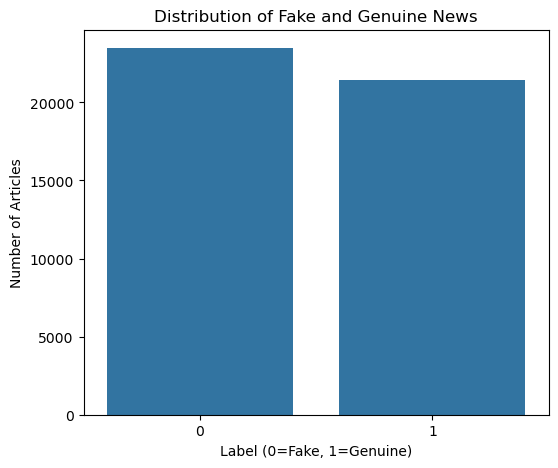

In [21]:
plt.figure(figsize=(6,5))

sns.countplot(x='label', data=news)

plt.title("Distribution of Fake and Genuine News")
plt.xlabel("Label (0=Fake, 1=Genuine)")
plt.ylabel("Number of Articles")

plt.show()

### Graph 2: Percentage Distribution
- Percentage Distribution of NewsCategories

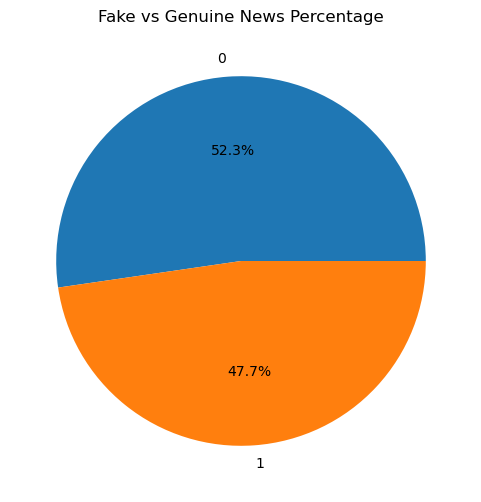

In [22]:
news['label'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title("Fake vs Genuine News Percentage")
plt.ylabel("")

plt.show()

### Graph 3: News Text Length Distribution
- Distribution of News Text Length

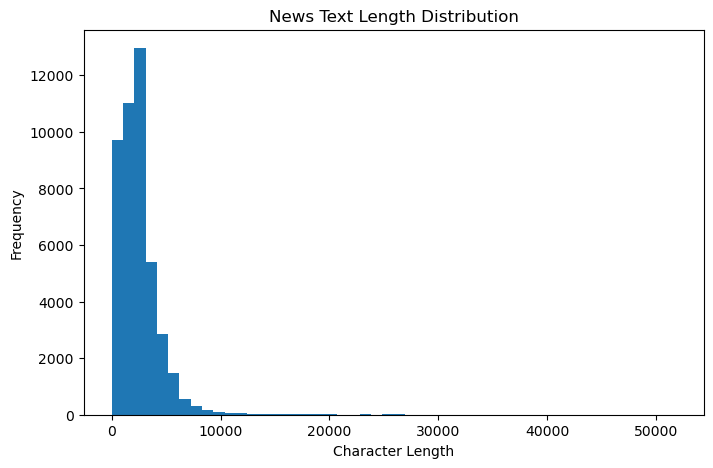

In [23]:
news['text_length'] = news['text'].apply(len)

plt.figure(figsize=(8,5))

plt.hist(news['text_length'], bins=50)

plt.title("News Text Length Distribution")
plt.xlabel("Character Length")
plt.ylabel("Frequency")

plt.show()

### Graph 3: Train-Test Split
- Train-Test Dataset Split

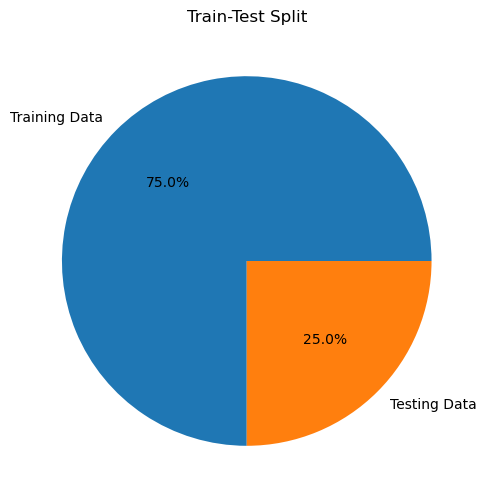

In [24]:
sizes = [75,25]

labels = ['Training Data','Testing Data']

plt.figure(figsize=(6,6))

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%'
)

plt.title("Train-Test Split")

plt.show()

### Text Cleaning
1. Lowercase
2. Remove URL's
3. Remove punctuations

In [25]:
import re       #regular expression

In [26]:
def wordopt(text):
    # Convert into lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)

    # Remove digits
    text = re.sub(r'\d', '', text)

    # Remove newline characters
    text = re.sub(r'\n', ' ', text)

    return text

In [27]:
news['text'] = news['text'].apply(wordopt)

In [28]:
news['text']

0        birmingham ala reuters  namecalling is not unu...
1        pepsi got hammered by just about everyone for ...
2        sarajevo reuters  police in the balkans have a...
3        washington reuters  criminal justice reform ad...
4        donald trump has done so many things that you ...
                               ...                        
44893    buenos aires reuters  a federal judge in argen...
44894    are democrat voters willing to risk what littl...
44895    hanoi reuters  us president donald trump said ...
44896    stories of governments removing citizens from ...
44897    reuters  a federal judge ruled on tuesday that...
Name: text, Length: 44898, dtype: object

### Assigning the values

In [29]:
x = news['text']
y = news['label']

In [30]:
x

0        birmingham ala reuters  namecalling is not unu...
1        pepsi got hammered by just about everyone for ...
2        sarajevo reuters  police in the balkans have a...
3        washington reuters  criminal justice reform ad...
4        donald trump has done so many things that you ...
                               ...                        
44893    buenos aires reuters  a federal judge in argen...
44894    are democrat voters willing to risk what littl...
44895    hanoi reuters  us president donald trump said ...
44896    stories of governments removing citizens from ...
44897    reuters  a federal judge ruled on tuesday that...
Name: text, Length: 44898, dtype: object

In [31]:
y

0        1
1        0
2        1
3        1
4        0
        ..
44893    1
44894    0
44895    1
44896    0
44897    1
Name: label, Length: 44898, dtype: int64

### Train test split

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3)

In [34]:
x_train.shape

(31428,)

In [35]:
x_test.shape

(13470,)

### TF-IDF Vectorization

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [37]:
vectorization = TfidfVectorizer()

In [38]:
xv_train = vectorization.fit_transform(x_train)

In [39]:
xv_test = vectorization.transform(x_test)

In [40]:
xv_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 6453047 stored elements and shape (31428, 175299)>

In [41]:
xv_test

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2728306 stored elements and shape (13470, 175299)>

## Model Training

### Logistic Regression

In [42]:
from sklearn.linear_model import LogisticRegression

In [43]:
LR = LogisticRegression()

In [44]:
LR.fit(xv_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [45]:
pred_lr = LR.predict(xv_test)

In [46]:
LR.score(xv_test, y_test)

0.987305122494432

In [47]:
from sklearn.metrics import classification_report

In [48]:
print(classification_report(y_test,pred_lr))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7051
           1       0.98      0.99      0.99      6419

    accuracy                           0.99     13470
   macro avg       0.99      0.99      0.99     13470
weighted avg       0.99      0.99      0.99     13470



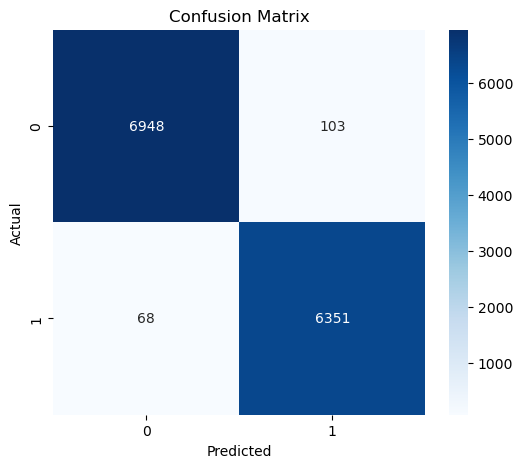

In [49]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred_lr)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Decision Tree Classifier

In [50]:
from sklearn.tree import DecisionTreeClassifier

In [51]:
Dtc = DecisionTreeClassifier()

In [52]:
Dtc.fit(xv_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [53]:
pred_dtc = Dtc.predict(xv_test)

In [54]:
Dtc.score(xv_test,y_test)

0.9962138084632517

In [55]:
print(classification_report(y_test,pred_dtc))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7051
           1       1.00      0.99      1.00      6419

    accuracy                           1.00     13470
   macro avg       1.00      1.00      1.00     13470
weighted avg       1.00      1.00      1.00     13470



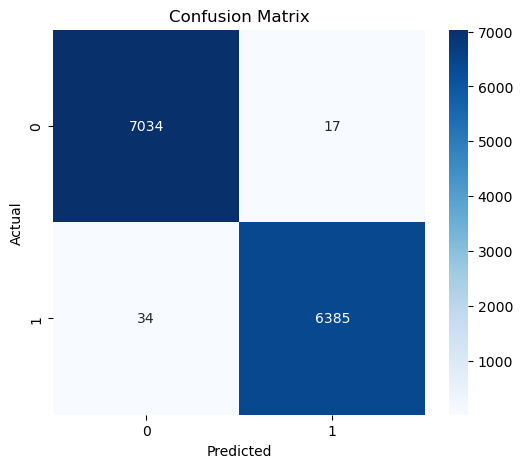

In [56]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred_dtc)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Random Forest

In [57]:
from sklearn.ensemble import RandomForestClassifier

In [58]:
rfc = RandomForestClassifier()

In [59]:
rfc.fit(xv_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [60]:
pred_rfc = rfc.predict(xv_test)

In [61]:
rfc.score(xv_test,y_test)

0.9894580549368968

In [62]:
print(classification_report(y_test,pred_rfc))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7051
           1       0.99      0.99      0.99      6419

    accuracy                           0.99     13470
   macro avg       0.99      0.99      0.99     13470
weighted avg       0.99      0.99      0.99     13470



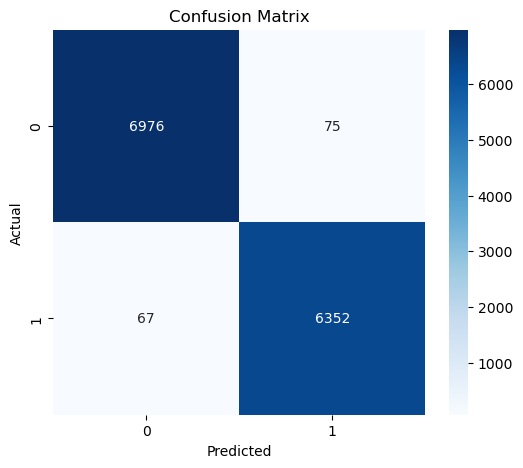

In [63]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred_rfc)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Gradient Boosting

In [68]:
from sklearn.ensemble import  GradientBoostingClassifier

In [69]:
gbc = GradientBoostingClassifier()

In [70]:
gbc.fit(xv_train,y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [71]:
pred_gbc = gbc.predict(xv_test)

In [72]:
gbc.score(xv_test,y_test)

0.9951002227171493

In [73]:
print(classification_report(y_test,pred_gbc))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      7012
           1       0.99      1.00      0.99      6458

    accuracy                           1.00     13470
   macro avg       0.99      1.00      1.00     13470
weighted avg       1.00      1.00      1.00     13470



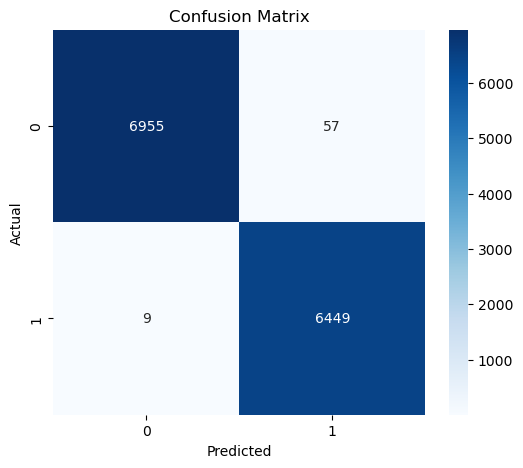

In [74]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred_gbc)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [76]:
def output_label(n):
    if n == 0:
        return 'It is a Fake News'
    elif n == 1:
        return 'It is a Genuine News'
        

In [77]:
def manual_testing(news):
    testing_news = {"text": [news]}

    new_def_test = pd.DataFrame(testing_news)
    new_def_test["text"] = new_def_test["text"].apply(wordopt)

    new_x_test = new_def_test["text"]
    new_xv_test = vectorization.transform(new_x_test)

    pred_lr = LR.predict(new_xv_test)
    # pred_dtc = dtc.predict(new_xv_test)
    pred_gbc = gbc.predict(new_xv_test)
    pred_rfc = rfc.predict(new_xv_test)

    return "\n\nLR Prediction: {} \tGBC Prediction: {} \tRFC Prediction: {}".format(
        output_label(pred_lr[0]),
        output_label(pred_gbc[0]),
        output_label(pred_rfc[0])
    )

In [78]:
news_article = str(input())

 Scientists have confirmed that drinking 10 cups of coffee every day can make humans live up to 150 years. The study claims that people who consume excessive coffee never suffer from any diseases and remain young forever.


In [79]:
manual_testing(news_article)

'\n\nLR Prediction: It is a Fake News \tGBC Prediction: It is a Fake News \tRFC Prediction: It is a Fake News'

### Results

The Fake News Detection system successfully classified news articles as Fake or Genuine using Machine Learning techniques.

Performance comparison showed that ensemble models such as Random Forest and Gradient Boosting achieved higher accuracy compared to individual classifiers.

The TF-IDF feature extraction method effectively transformed textual data into machine-readable numerical format, improving classification performance.

### Conclusion

This project demonstrates the effectiveness of Machine Learning techniques in detecting fake news articles automatically. By applying text preprocessing, TF-IDF vectorization, and multiple classification algorithms, the system achieved reliable prediction results.

The developed model can help reduce the spread of misinformation and support users in identifying trustworthy news content. Future enhancements may include Deep Learning techniques, real-time news verification, and integration with social media platforms for automated fake news detection.

## Final Outcome: 
        Fake News Detection System Successfully Developed and Tested Using Machine Learning Algorithms.